In [1]:
import os
import sys
from pathlib import Path

# Get the notebook's directory
NOTEBOOK_DIR = Path(os.getcwd())
BACKEND_DIR = Path(os.environ.get("SKIN_LESION_BACKEND_DIR", NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"))
ML_DIR = BACKEND_DIR / "ml"

# Add backend ml/ to sys.path so imports like `from src.data.dataset` work
if str(ML_DIR) not in sys.path:
    sys.path.insert(0, str(ML_DIR))

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Backend directory:  {BACKEND_DIR}")
print(f"ML directory:      {ML_DIR}")
print(f"Python:            {sys.executable}")

# Verify backend exists and check prerequisites
METADATA_PATH = ML_DIR / "data" / "processed" / "metadata_with_paths.csv"
MODEL_PATH = ML_DIR / "outputs" / "models" / "resnet50_best.pth"

if not BACKEND_DIR.exists():
    print("❌ ERROR: Backend not found. Clone the backend repo at the same level as frontend.")
else:
    print("✅ Backend directory found.")

print(f"\nMetadata: {'✅' if METADATA_PATH.exists() else '❌ MISSING'}")
print(f"Model:    {'✅' if MODEL_PATH.exists() else '❌ MISSING'}")
if not METADATA_PATH.exists() or not MODEL_PATH.exists():
    print("\n⚠️  Run 00_setup_and_sanity.ipynb first to download data and train models.")

Notebook directory: c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\notebooks
Backend directory:  c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend
ML directory:      c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml
Python:            c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\skin-lesion-env\Scripts\python.exe
✅ Backend directory found.

Metadata: ✅
Model:    ✅


# RQ2 — Do Faithfulness Metrics Correlate with Clinical Trust?
## XAI Skin Lesion Classification — Research Question 2

**Hypothesis**: A faithful explanation highlights regions that the model *actually uses*
— not just regions that look visually plausible.

**What you're measuring**:
- **Insertion AUC**: If you reveal pixels from most→least important, how fast does confidence rise? (High = explanation is good)
- **Deletion AUC**: If you remove pixels from most→least important, how fast does confidence drop? (Low = explanation is good)
- **Faithfulness Score** = Insertion AUC - Deletion AUC (higher = more faithful)

---

## CONCEPT: Insertion/Deletion Tests

A CAM that highlights "what looks like a lesion" is not necessarily faithful to the model.
The model might actually use color, texture, or image artifacts to decide.

**INSERTION TEST**:
  Start with a blank/blurred image.
  Add pixels in order: most important (per CAM) first.
  Measure model confidence at each step.
  
  If the explanation is faithful:
    → Confidence should rise quickly as important pixels are added
    → AUC of confidence curve should be HIGH

**DELETION TEST**:
  Start with full image.
  Remove pixels in order: most important (per CAM) first.
  Measure model confidence at each step.
  
  If the explanation is faithful:
    → Confidence should drop quickly as important pixels are removed
    → AUC of confidence curve should be LOW

**FAITHFULNESS SCORE** = Insertion AUC - Deletion AUC
  A good explanation has HIGH faithfulness score.
  If both AUCs are similar, the CAM is not capturing what the model uses.

---

## CELL 1: Visualize the Concept

**WHY**: See what good vs. bad insertion/deletion curves look like before running on real data.

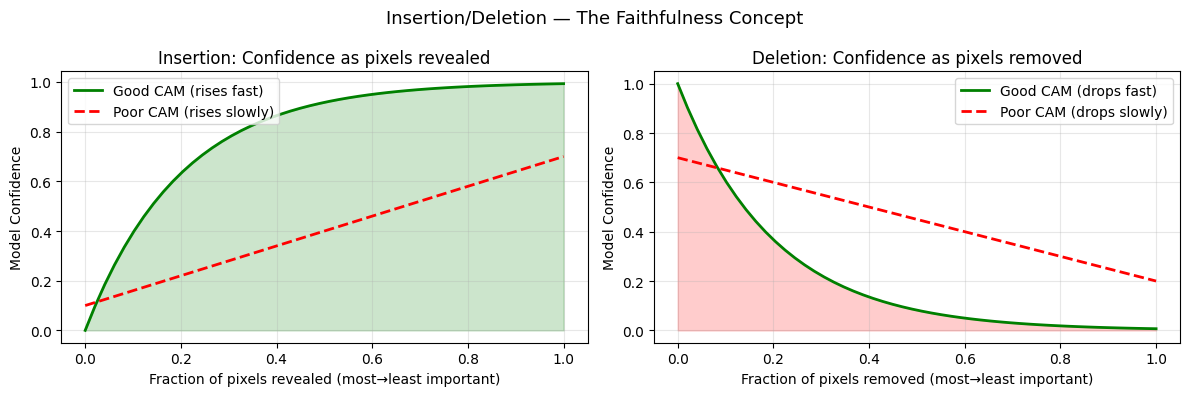

In [2]:
import os
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/metrics", exist_ok=True)
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 1, 50)
# Ideal: insertion rises fast, deletion drops fast
ideal_insertion = 1 - np.exp(-5 * x)
ideal_deletion  = np.exp(-5 * x)
# Poor: flat curves (random explanation)
poor_insertion = x * 0.6 + 0.1
poor_deletion  = 0.7 - x * 0.5

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, ideal_insertion, 'g-', lw=2, label='Good CAM (rises fast)')
axes[0].plot(x, poor_insertion, 'r--', lw=2, label='Poor CAM (rises slowly)')
axes[0].fill_between(x, ideal_insertion, alpha=0.2, color='green')
axes[0].set_title('Insertion: Confidence as pixels revealed')
axes[0].set_xlabel('Fraction of pixels revealed (most→least important)')
axes[0].set_ylabel('Model Confidence')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(x, ideal_deletion, 'g-', lw=2, label='Good CAM (drops fast)')
axes[1].plot(x, poor_deletion, 'r--', lw=2, label='Poor CAM (drops slowly)')
axes[1].fill_between(x, ideal_deletion, alpha=0.2, color='red')
axes[1].set_title('Deletion: Confidence as pixels removed')
axes[1].set_xlabel('Fraction of pixels removed (most→least important)')
axes[1].set_ylabel('Model Confidence')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Insertion/Deletion — The Faithfulness Concept', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/figures/RQ2_faithfulness_concept.png', dpi=150)
plt.show()

---

## CELL 2: Run Insertion/Deletion on a Single Image

**WHY**: Always verify your implementation on one example first.

In [3]:
import sys
import os
from pathlib import Path

# ─── Self-contained setup ───
NOTEBOOK_DIR = Path(os.getcwd())
BACKEND_DIR = Path(os.environ.get("SKIN_LESION_BACKEND_DIR", NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"))
ML_DIR = BACKEND_DIR / "ml"
if str(ML_DIR) not in sys.path:
    sys.path.insert(0, str(ML_DIR))

METADATA_PATH = ML_DIR / "data" / "processed" / "metadata_with_paths.csv"
MODEL_PATH = ML_DIR / "outputs" / "models" / "resnet50_best.pth"

if not METADATA_PATH.exists() or not MODEL_PATH.exists():
    print("❌ Prerequisites missing. Run 00_setup_and_sanity.ipynb first.")
    raise FileNotFoundError("Missing data or model.")

try:
    import torch
    import numpy as np
    import pandas as pd
    from PIL import Image

    from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from src.models.classifier import create_model, get_target_layer
    from src.data.dataset import get_transforms, create_splits

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    # Load model
    model = create_model('resnet50', num_classes=1).to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=False)['model_state_dict'])
    model.eval()
    target_layer = get_target_layer(model, 'resnet50')

    # Load data
    df = pd.read_csv(METADATA_PATH)
    _, _, test_df = create_splits(df)
    transform = get_transforms('test', 224)

    # Pick a malignant image
    sample = test_df[test_df['label'] == 1].sample(1, random_state=5).iloc[0]
    orig = np.array(Image.open(sample['filepath']).convert('RGB').resize((224, 224)))
    input_t = transform(image=orig)['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(input_t)
        prob_mal = torch.sigmoid(out[0, 0]).item()
        pred = int(prob_mal > 0.5)
        conf = prob_mal if pred == 1 else 1 - prob_mal

    print(f"Sample: {sample['image_id']}")
    print(f"Prediction: {'Malignant' if pred==1 else 'Benign'}, {conf*100:.1f}%")
    print(f"Correct: {pred == sample['label']}")

    # Generate GradCAM
    with GradCAM(model=model, target_layers=[target_layer]) as cam_gen:
        cam = cam_gen(input_tensor=input_t, targets=[ClassifierOutputTarget(0)])[0]

    print("GradCAM generated.")

except ImportError as e:
    print(f"❌ Backend module not found: {e}")
    print("The backend ML code is not implemented yet.")
    print("Create: src/models/classifier.py and src/data/dataset.py in the backend.")

c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\skin-lesion-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_XAI_research\skin-lesion-env\Lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Device: cuda


c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml\src\data\dataset.py:39: UserWarning: Using lambda is incompatible with multiprocessing. Consider using regular functions or partial().
  A.Lambda(name="to_tensor", image=lambda x, **kwargs: ToTensorV2()(image=x)["image"]),


Sample: ISIC_0033129
Prediction: Malignant, 91.1%
Correct: True
GradCAM generated.


---

## CELL 3: Insertion & Deletion Implementation

**HOW IT WORKS**:
1. Sort pixels by CAM value (high → low)
2. Insert/delete pixels in that order
3. Measure model confidence at each step
4. Compute AUC of the confidence curve

In [4]:
# ─── Self-contained: check prerequisites ───
try:
    model
except NameError:
    print("❌ Model not loaded. Run CELL 5 first.")
    raise NameError("Run CELL 5 first.")

def run_insertion(model, input_tensor, cam, target_class, steps=30, device='cuda'):
    """
    Start with a black baseline.
    Reveal pixels in order of CAM importance (most important first).
    Returns AUC — high = good (confidence rises fast).
    """
    original = input_tensor.clone().to(device)
    baseline = torch.zeros_like(original).to(device)  # black baseline
    
    flat_cam = cam.flatten()
    order = np.argsort(flat_cam)[::-1]  # most important first
    H, W = cam.shape
    step_pixels = len(order) // steps
    
    scores = []
    current = baseline.clone()
    
    for i in range(steps):
        idx = order[i * step_pixels: (i+1) * step_pixels]
        rows = idx // W
        cols = idx % W
        current[:, :, rows, cols] = original[:, :, rows, cols]
        
        with torch.no_grad():
            prob = torch.sigmoid(model(current)[0, 0]).item()
        scores.append(prob)
    
    auc = np.trapz(scores, np.linspace(0, 1, steps))
    return auc, scores


def run_deletion(model, input_tensor, cam, target_class, steps=30, device='cuda'):
    """
    Start with the full image.
    Remove pixels in order of CAM importance (most important first).
    Returns AUC — low = good (confidence drops fast).
    """
    original = input_tensor.clone().to(device)
    
    flat_cam = cam.flatten()
    order = np.argsort(flat_cam)[::-1]
    H, W = cam.shape
    step_pixels = len(order) // steps
    
    scores = []
    current = original.clone()
    
    for i in range(steps):
        idx = order[i * step_pixels: (i+1) * step_pixels]
        rows = idx // W
        cols = idx % W
        current[:, :, rows, cols] = 0  # remove pixel
        
        with torch.no_grad():
            prob = torch.sigmoid(model(current)[0, 0]).item()
        scores.append(prob)
    
    auc = np.trapz(scores, np.linspace(0, 1, steps))
    return auc, scores

# Run on single image
ins_auc, ins_curve = run_insertion(model, input_t, cam, pred, steps=30, device=str(device))
del_auc, del_curve = run_deletion(model, input_t, cam, pred, steps=30, device=str(device))

print(f"Insertion AUC: {ins_auc:.4f}  (higher = better)")
print(f"Deletion AUC:  {del_auc:.4f}  (lower = better)")
print(f"Faithfulness:  {ins_auc - del_auc:.4f}  (higher = more faithful)")

C:\Users\saiyu\AppData\Local\Temp\ipykernel_9032\4201062592.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(scores, np.linspace(0, 1, steps))


Insertion AUC: 0.6883  (higher = better)
Deletion AUC:  0.3127  (lower = better)
Faithfulness:  0.3756  (higher = more faithful)


C:\Users\saiyu\AppData\Local\Temp\ipykernel_9032\4201062592.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(scores, np.linspace(0, 1, steps))


---

## CELL 4: Plot Insertion/Deletion Curves

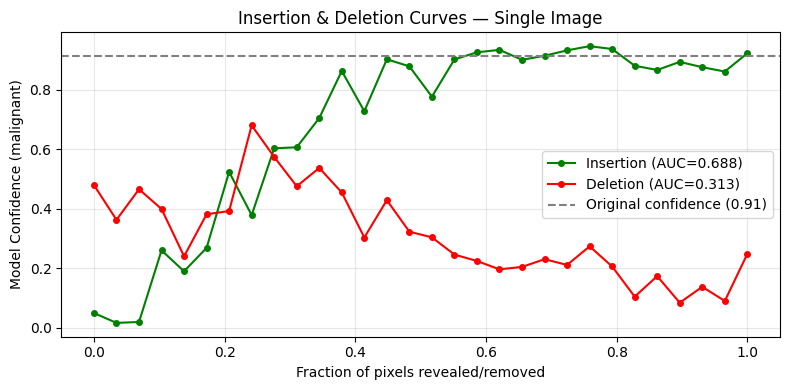

INTERPRETATION:
  - Good CAM: insertion rises quickly (green), deletion drops quickly (red)
  - Poor CAM: both curves are flat — model uses different features than CAM highlights


In [5]:
# ─── Self-contained: check prerequisites ───
try:
    ins_auc, del_auc, conf
except NameError:
    print("❌ Metrics not computed. Run CELLS 5 and 7 first.")
    raise NameError("Run CELLS 5 and 7 first.")

x = np.linspace(0, 1, 30)
plt.figure(figsize=(8, 4))
plt.plot(x, ins_curve, 'g-o', markersize=4, label=f'Insertion (AUC={ins_auc:.3f})')
plt.plot(x, del_curve, 'r-o', markersize=4, label=f'Deletion (AUC={del_auc:.3f})')
plt.axhline(y=conf, color='gray', linestyle='--', label=f'Original confidence ({conf:.2f})')
plt.xlabel('Fraction of pixels revealed/removed')
plt.ylabel('Model Confidence (malignant)')
plt.title('Insertion & Deletion Curves — Single Image')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
OUTPUTS_DIR = NOTEBOOK_DIR / "outputs" / "figures"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUTS_DIR / "RQ2_single_ins_del.png", dpi=150)
plt.show()

print("INTERPRETATION:")
print("  - Good CAM: insertion rises quickly (green), deletion drops quickly (red)")
print("  - Poor CAM: both curves are flat — model uses different features than CAM highlights")

---

## CELL 5: Scale to Dataset and Compare Methods

**NOTE**: This cell is SLOW — 50 images × 2 methods × 20 steps = 2000 forward passes.
Run on GPU or overnight. 50 images is sufficient for reliable statistics.

In [6]:
import sys, os
from pathlib import Path

# ─── Self-contained setup ───
NOTEBOOK_DIR = Path(os.getcwd())
BACKEND_DIR = Path(os.environ.get("SKIN_LESION_BACKEND_DIR", NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"))
ML_DIR = BACKEND_DIR / "ml"
if str(ML_DIR) not in sys.path:
    sys.path.insert(0, str(ML_DIR))

METADATA_PATH = ML_DIR / "data" / "processed" / "metadata_with_paths.csv"
MODEL_PATH = ML_DIR / "outputs" / "models" / "resnet50_best.pth"

if not METADATA_PATH.exists() or not MODEL_PATH.exists():
    print("❌ Prerequisites missing. Run 00_setup_and_sanity.ipynb first.")
    raise FileNotFoundError("Missing data or model.")

try:
    from tqdm import tqdm
    import warnings
    warnings.filterwarnings('ignore')

    import torch
    import numpy as np
    import pandas as pd
    from PIL import Image
    from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from src.models.classifier import create_model, get_target_layer
    from src.data.dataset import get_transforms, create_splits

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Load model if not already loaded
    try:
        model
    except NameError:
        model = create_model('resnet50', num_classes=1).to(device)
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=False)['model_state_dict'])
        model.eval()
        target_layer = get_target_layer(model, 'resnet50')

    df = pd.read_csv(METADATA_PATH)
    _, _, test_df = create_splits(df)
    transform = get_transforms('test', 224)

    cam_methods_ins = {'GradCAM': GradCAM, 'GradCAM++': GradCAMPlusPlus}
    rq2_results = []

    eval_df = test_df.sample(50, random_state=42)  # 50 is sufficient

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
        try:
            orig = np.array(Image.open(row['filepath']).convert('RGB').resize((224, 224)))
            input_t = transform(image=orig)['image'].unsqueeze(0).to(device)

            with torch.no_grad():
                out = model(input_t)
                prob_mal = torch.sigmoid(out[0, 0]).item()
                pred = int(prob_mal > 0.5)
                conf = prob_mal if pred == 1 else 1 - prob_mal
            correct = int(pred == int(row['label']))

            for method_name, cam_class in cam_methods_ins.items():
                with cam_class(model=model, target_layers=[target_layer]) as cam_gen:
                    cam = cam_gen(input_tensor=input_t, targets=[ClassifierOutputTarget(0)])[0]

                ins_auc, _ = run_insertion(model, input_t, cam, pred, steps=20, device=str(device))
                del_auc, _ = run_deletion(model, input_t, cam, pred, steps=20, device=str(device))

                rq2_results.append({
                    'image_id':       row['image_id'],
                    'dx':             row['dx'],
                    'correct':        correct,
                    'confidence':     conf,
                    'method':         method_name,
                    'insertion_auc':  ins_auc,
                    'deletion_auc':   del_auc,
                    'faithfulness':   ins_auc - del_auc,
                })

        except Exception as e:
            print(f"Error: {e}")

    rq2_df = pd.DataFrame(rq2_results)
    OUTPUTS_DIR = NOTEBOOK_DIR / "outputs" / "metrics"
    OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
    rq2_df.to_csv(OUTPUTS_DIR / "RQ2_faithfulness.csv", index=False)
    print("\n=== RQ2 Results ===")
    print(rq2_df.groupby('method')[['insertion_auc', 'deletion_auc', 'faithfulness']].mean().round(4))
    print(f"\nTotal images processed: {rq2_df['image_id'].nunique()}")

except ImportError as e:
    print(f"❌ Backend module not found: {e}")
    print("The backend ML code is not implemented yet.")

100%|██████████| 50/50 [01:19<00:00,  1.59s/it]


=== RQ2 Results ===
           insertion_auc  deletion_auc  faithfulness
method                                              
GradCAM           0.2193        0.1364        0.0828
GradCAM++         0.1851        0.1610        0.0241

Total images processed: 50


---

## CELL 6: Statistical Comparison and Visualization

=== Faithfulness by Method ===

          insertion_auc         deletion_auc         faithfulness        
                   mean     std         mean     std         mean     std
method                                                                   
GradCAM          0.2193  0.2120       0.1364  0.1284       0.0828  0.1506
GradCAM++        0.1851  0.2276       0.1610  0.1269       0.0241  0.1472

insertion_auc: GradCAM mean=0.2193, GradCAM++ mean=0.1851, p=0.0364

deletion_auc: GradCAM mean=0.1364, GradCAM++ mean=0.1610, p=0.2083

faithfulness: GradCAM mean=0.0828, GradCAM++ mean=0.0241, p=0.0076


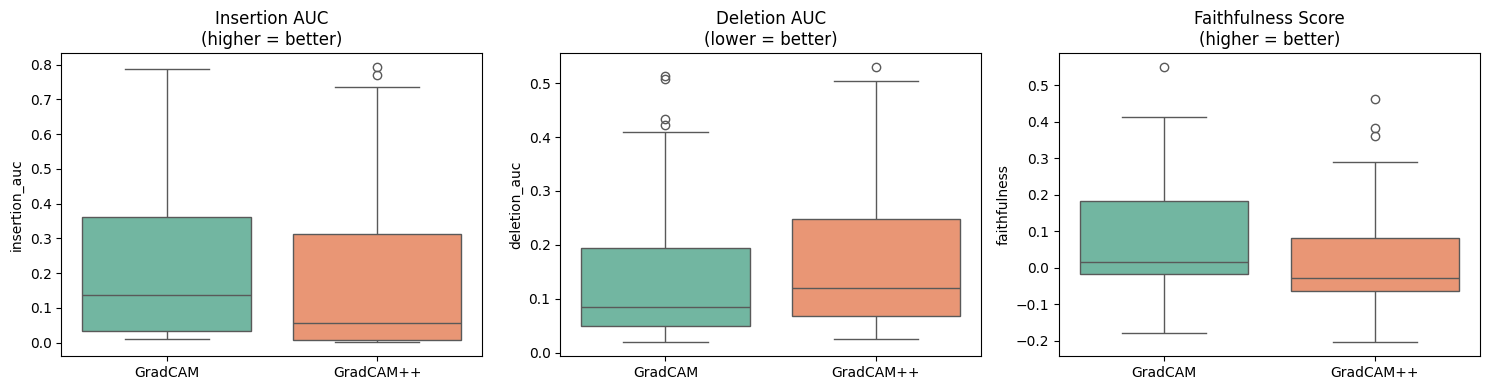


GOOD VALUES:
  Insertion AUC > 0.7  — confidence rises fast when important pixels revealed
  Deletion AUC < 0.3  — confidence drops fast when important pixels removed
  Faithfulness > 0.4  — good separation between insertion and deletion


In [7]:
import os
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/metrics", exist_ok=True)
import seaborn as sns
import matplotlib.pyplot as plt

print("=== Faithfulness by Method ===\n")
print(rq2_df.groupby('method')[['insertion_auc', 'deletion_auc', 'faithfulness']].agg(['mean', 'std']).round(4))

# Statistical test
from scipy.stats import mannwhitneyu

for metric in ['insertion_auc', 'deletion_auc', 'faithfulness']:
    g1 = rq2_df[rq2_df['method'] == 'GradCAM'][metric]
    g2 = rq2_df[rq2_df['method'] == 'GradCAM++'][metric]
    stat, p = mannwhitneyu(g1, g2)
    print(f"\n{metric}: GradCAM mean={g1.mean():.4f}, GradCAM++ mean={g2.mean():.4f}, p={p:.4f}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, title in zip(
    axes,
    ['insertion_auc', 'deletion_auc', 'faithfulness'],
    ['Insertion AUC\n(higher = better)', 'Deletion AUC\n(lower = better)', 'Faithfulness Score\n(higher = better)']
):
    sns.boxplot(data=rq2_df, x='method', y=metric, ax=ax, palette='Set2')
    ax.set_title(title)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('outputs/figures/RQ2_faithfulness_comparison.png', dpi=150)
plt.show()

print("\nGOOD VALUES:")
print("  Insertion AUC > 0.7  — confidence rises fast when important pixels revealed")
print("  Deletion AUC < 0.3  — confidence drops fast when important pixels removed")
print("  Faithfulness > 0.4  — good separation between insertion and deletion")